# NEP5 – afkastanalyse

Hvad har vores investering givet pr. periode, hvor kommer resultatet fra, hvad koster
forvaltningen, og hvad er afkastet i DKK? Analysen er **investorniveau**: vores pengestrømme, vores
NAV og vores kapitalkonto, efter honorar og carry.

Al logik ligger i `pe_analysis/afkast/`; notebooken vælger fonden og kalder én metode pr. slide.
Hver metode gemmer en PNG i `charts/`, og de sidste celler skriver Excel og PowerPoint til
`exports/`.

> Hvilke slides der tegnes, afgøres af fondens data. En metode, der mangler det, den skal bruge
> (honorar udskilt i kapitalkontoen, indkald opdelt efter formål, anden valuta end DKK ...), skriver
> hvorfor og springer over.

In [1]:
from pe_analysis.afkast import Afkast

## Konfiguration

In [2]:
FUND_CODE   = "NEP5"
AS_OF       = None             # None = seneste NAV-dato; ellers fx "2025-12-31"
NAV_KOLONNE = "restated_nav"   # reviderede årsultimoer; "nav" = som først rapporteret

## Indlæsning og afstemning

Perioderne skal summere til nettoresultatet, kapitalkontoens linjer til NAV, og valutabroens led
til værdien i DKK, før noget tegnes.

In [3]:
af = Afkast(FUND_CODE, as_of=AS_OF, nav_kolonne=NAV_KOLONNE)

Afstemning:
  Periodernes værdiskabelse              29.525.608  mod       29.525.608  (NAV + akk. nettopengestrøm)
  Kapitalkontoens linjer i alt          100.906.422  mod      100.906.424  (vores NAV)  afvigelse -2
  Kapitalkontoens nettoresultat          29.525.608  mod       29.525.608  (merværdi af vores pengestrømme)
  Valutabro i DKK                       836.071.577  mod      836.071.577  (NAV + udloddet i DKK)
NEP5: Newbury Equity Partners V · pr. 30.06.2026 · USD · 25 opgørelser · kapitalkonto siden start: ja · honorar opdelt: nej · valuta: ja


# 1. Periodeafkast

Hvad har investeringen givet pr. kvartal, over 12 måneder og pr. horisont? Værdiskabelse er ændringen i NAV plus udlodninger minus indbetalinger; procenten er Modified Dietz på de faktiske valørdatoer.

gemt: charts\nep5_afkast_noegletal.png  (3200 x 1800 px · 16:9)


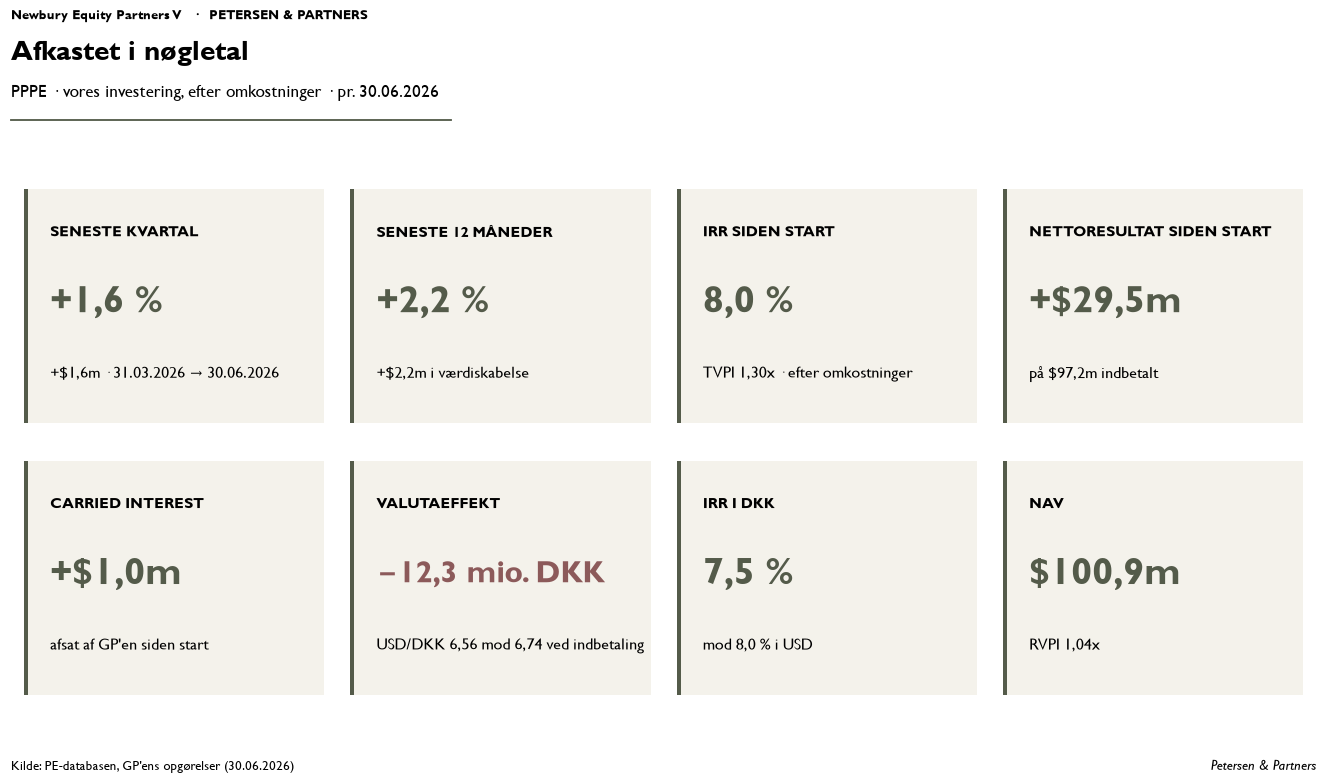

In [4]:
af.graf_noegletal()

gemt: charts\nep5_afkast_kvartalsafkast.png  (3200 x 1800 px · 16:9)


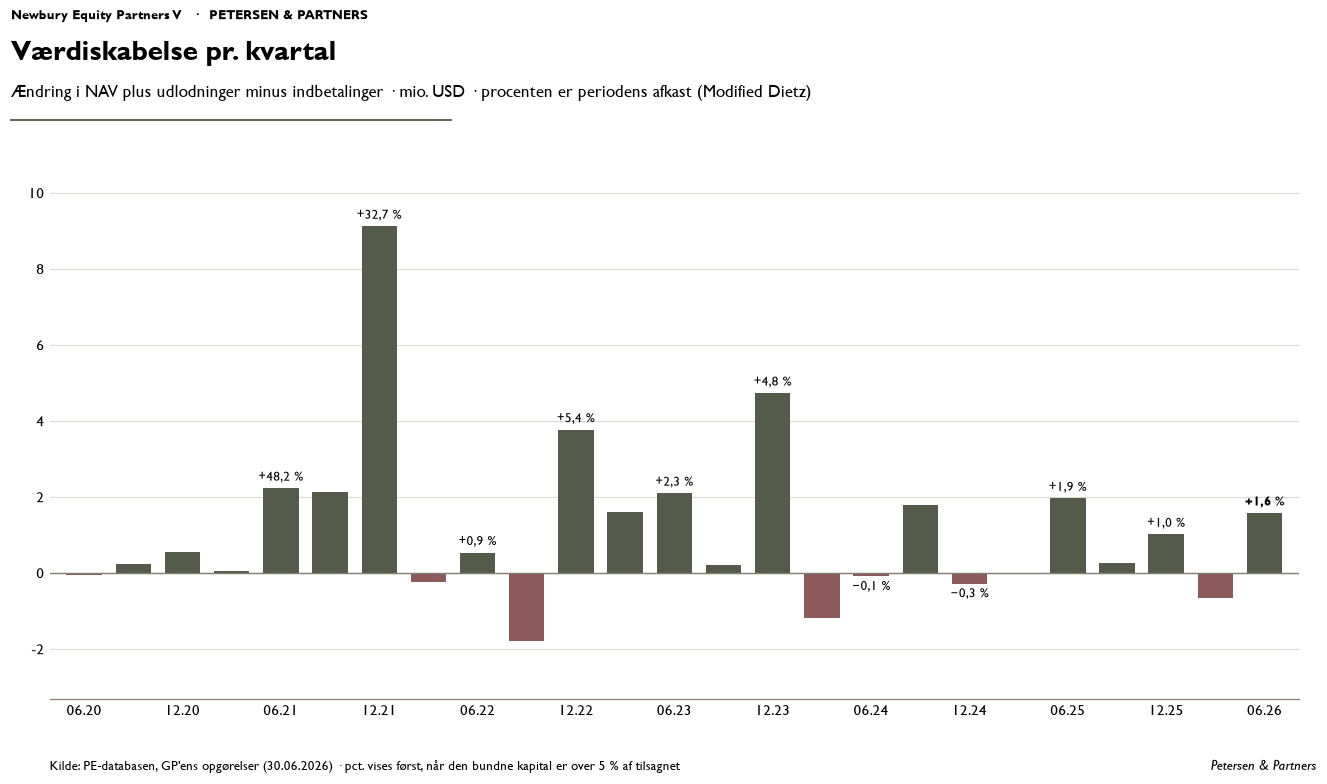

In [5]:
af.graf_kvartalsafkast()

gemt: charts\nep5_afkast_rullende.png  (3200 x 1800 px · 16:9)


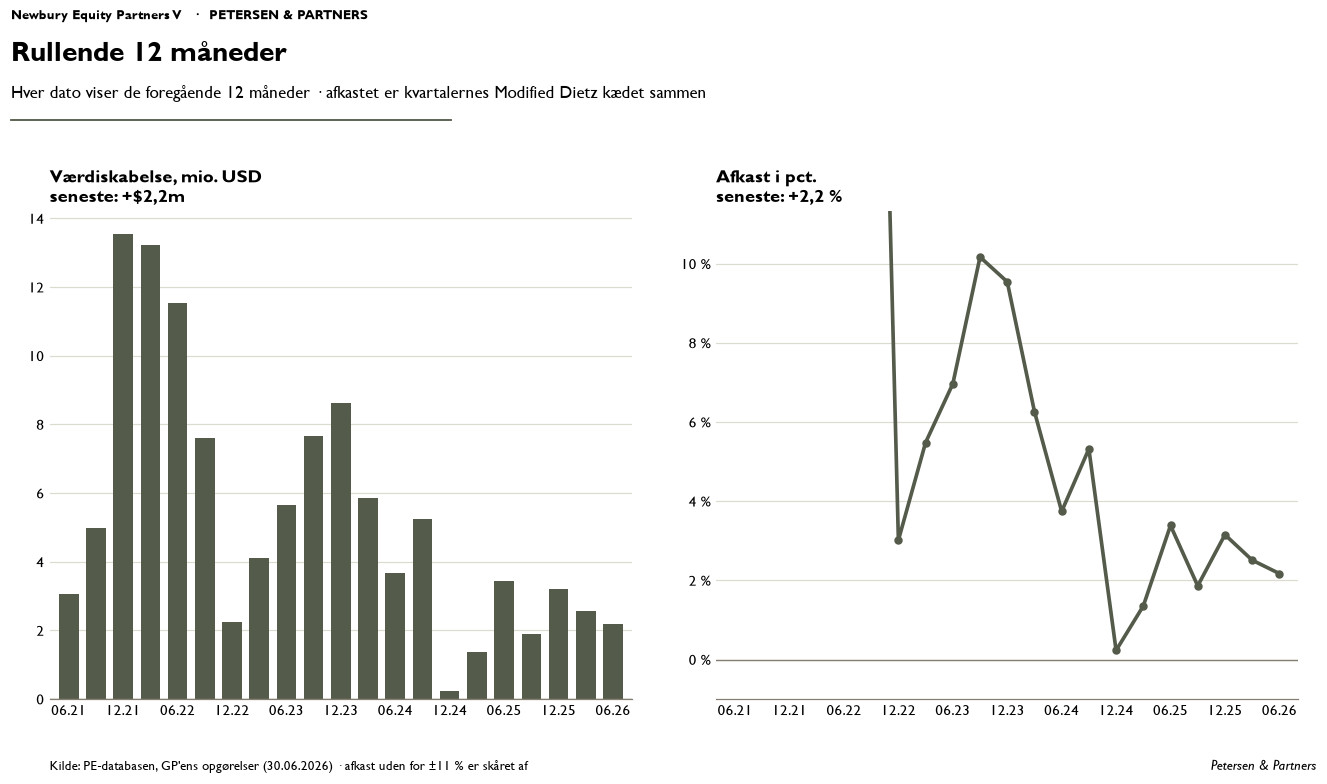

In [6]:
af.graf_rullende()

gemt: charts\nep5_afkast_horisont.png  (3200 x 1800 px · 16:9)


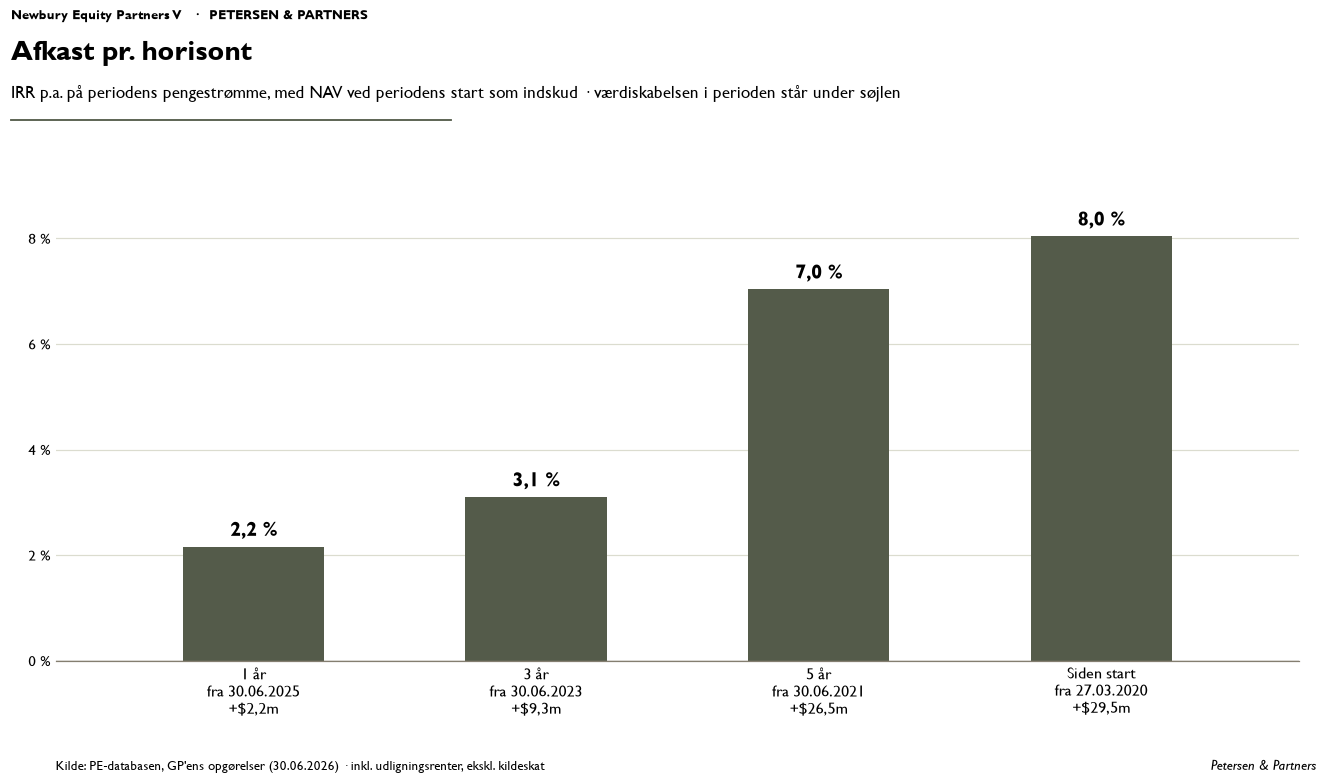

In [7]:
af.graf_horisont()

# 2. Afkastets kilder og omkostninger

Kapitalkontoens linjer lagt sammen siden start: hvad er indtægt, realiseret og urealiseret, og hvor meget af bruttoresultatet går til honorar, omkostninger og carry?

gemt: charts\nep5_afkast_kilder_tid.png  (3200 x 1800 px · 16:9)


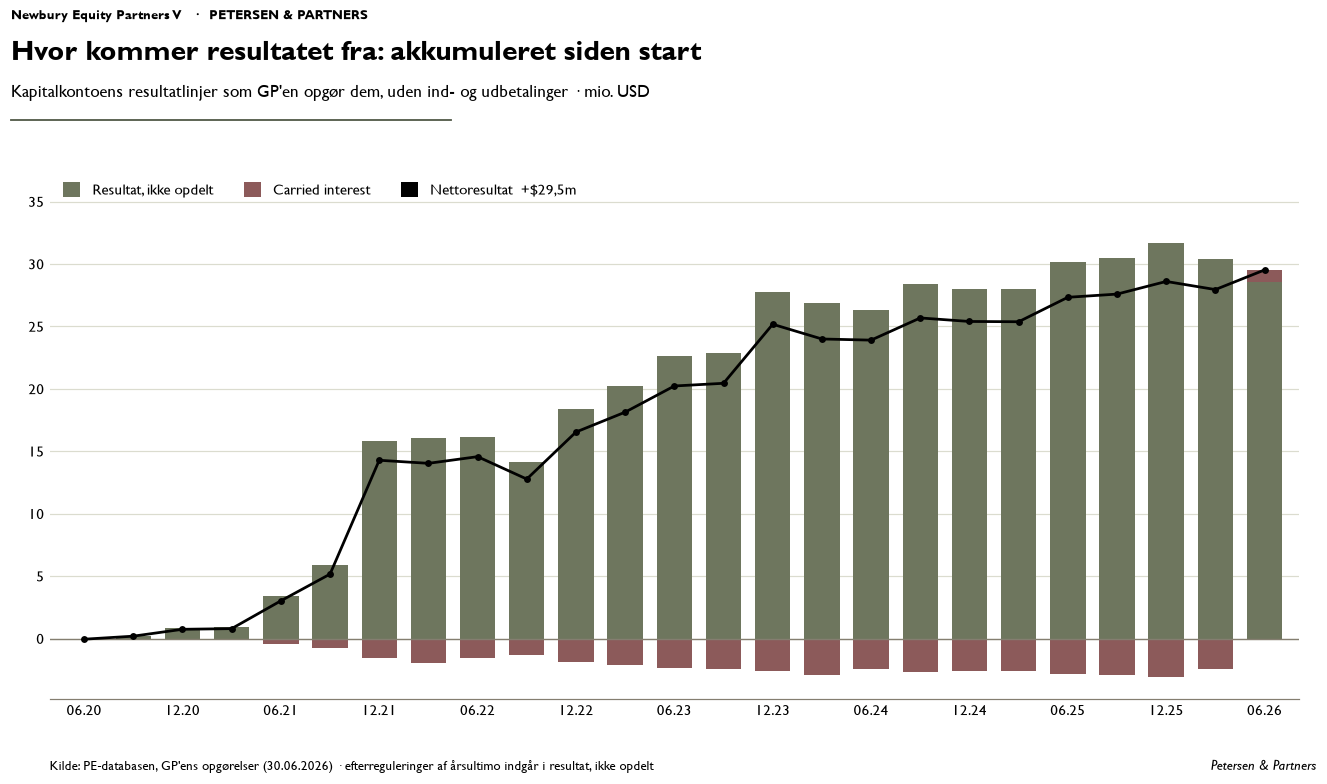

In [8]:
af.graf_kilder_tid()

gemt: charts\nep5_afkast_kilder_aar.png  (3200 x 1800 px · 16:9)


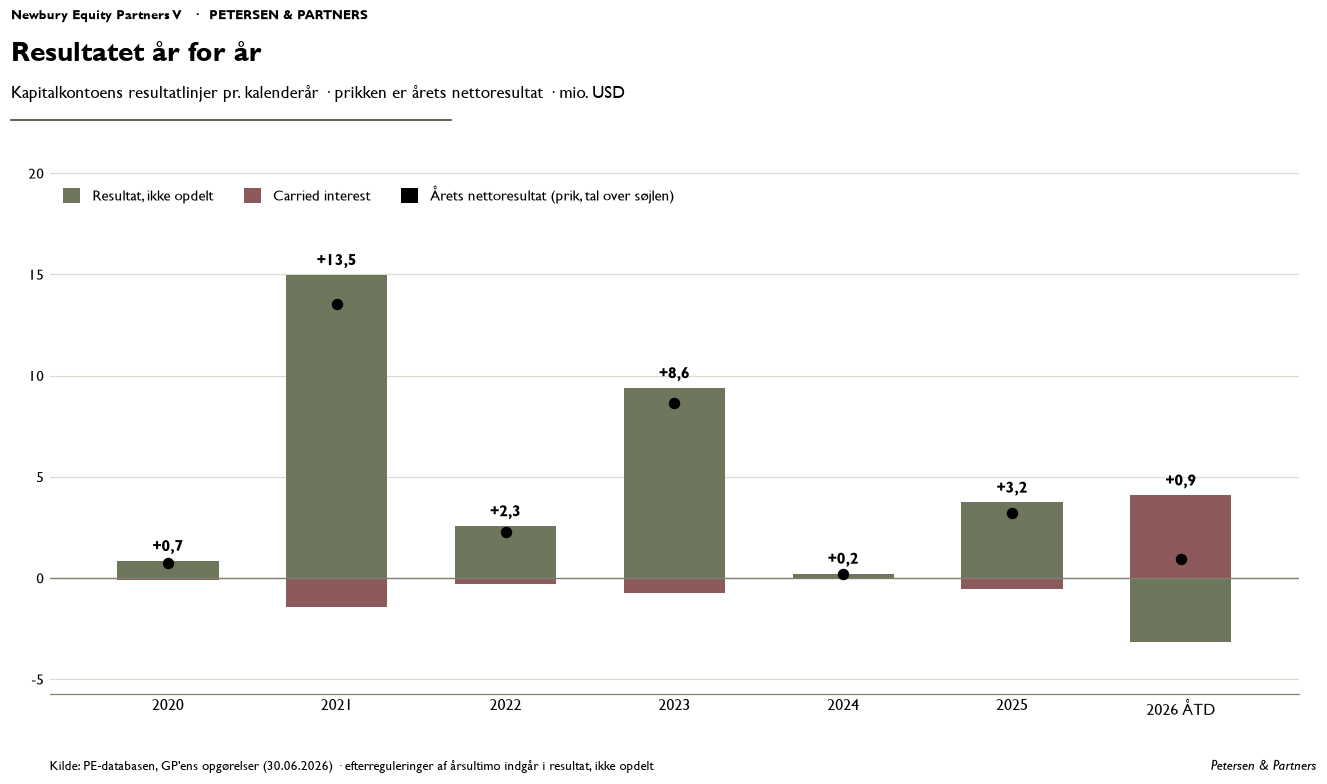

In [9]:
af.graf_kilder_aar()

gemt: charts\nep5_afkast_brutto_netto.png  (3200 x 1800 px · 16:9)


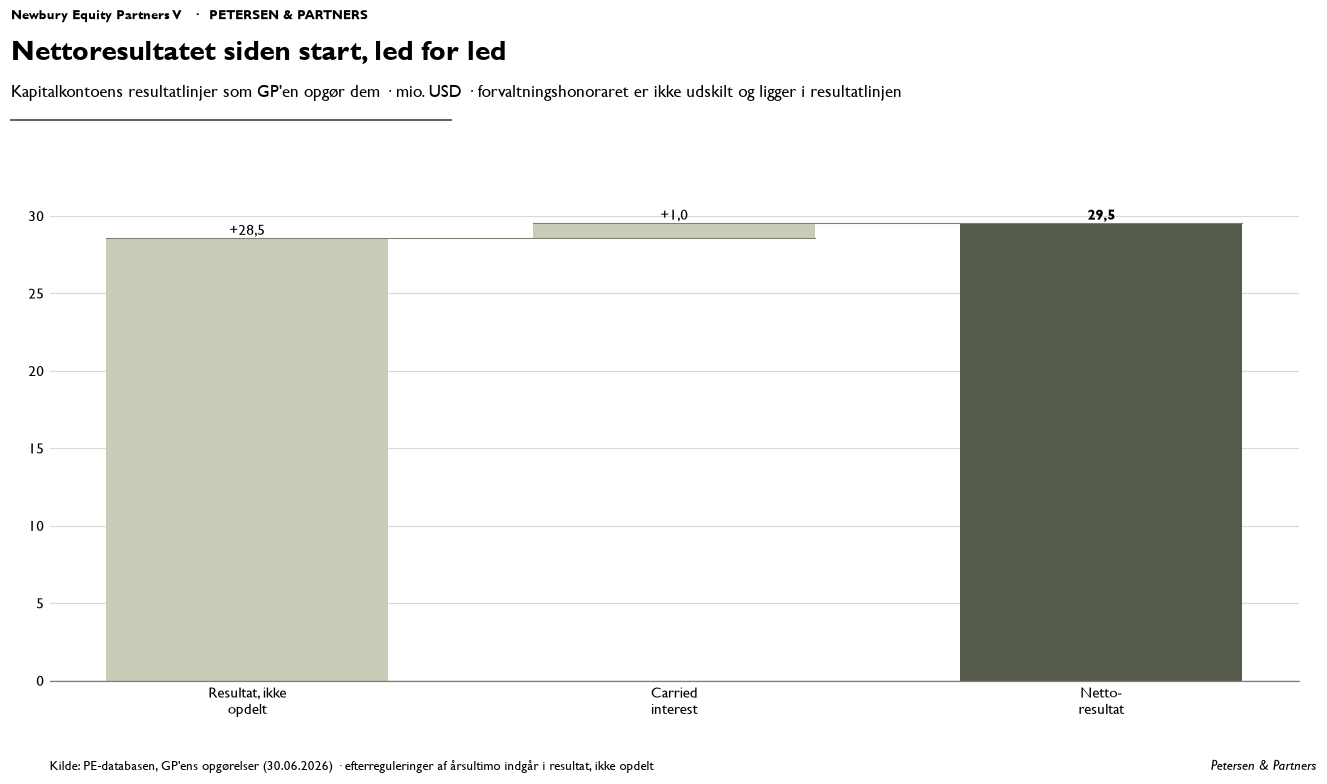

In [10]:
af.graf_brutto_netto()

In [11]:
af.graf_omkostninger()

Ingen forvaltningshonorar udskilt i kapitalkontoen for NEP5 - springer over


# 3. Kapitalens anvendelse

Hvad er indkaldene gået til, hvad består udlodningerne af, og hvor meget af tilsagnet står tilbage?

In [12]:
af.graf_formaal()

Ingen indkald opdelt efter formål i meddelelserne for NEP5 - springer over


gemt: charts\nep5_afkast_tilsagn.png  (3200 x 1800 px · 16:9)


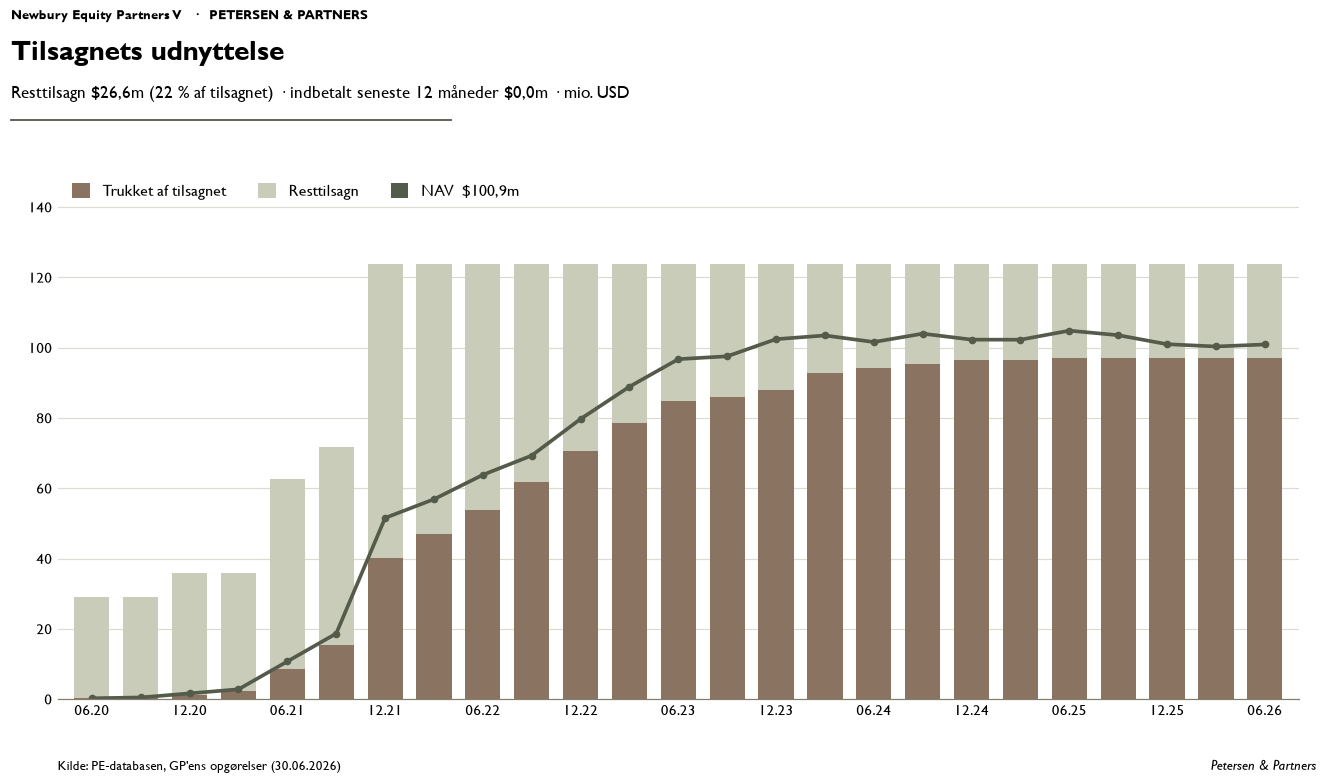

In [13]:
af.graf_tilsagn()

# 4. Valuta

Afkastet i DKK delt i fondens afkast og valutaens bidrag. Kun fonde i anden valuta.

gemt: charts\nep5_afkast_valutabro.png  (3200 x 1800 px · 16:9)


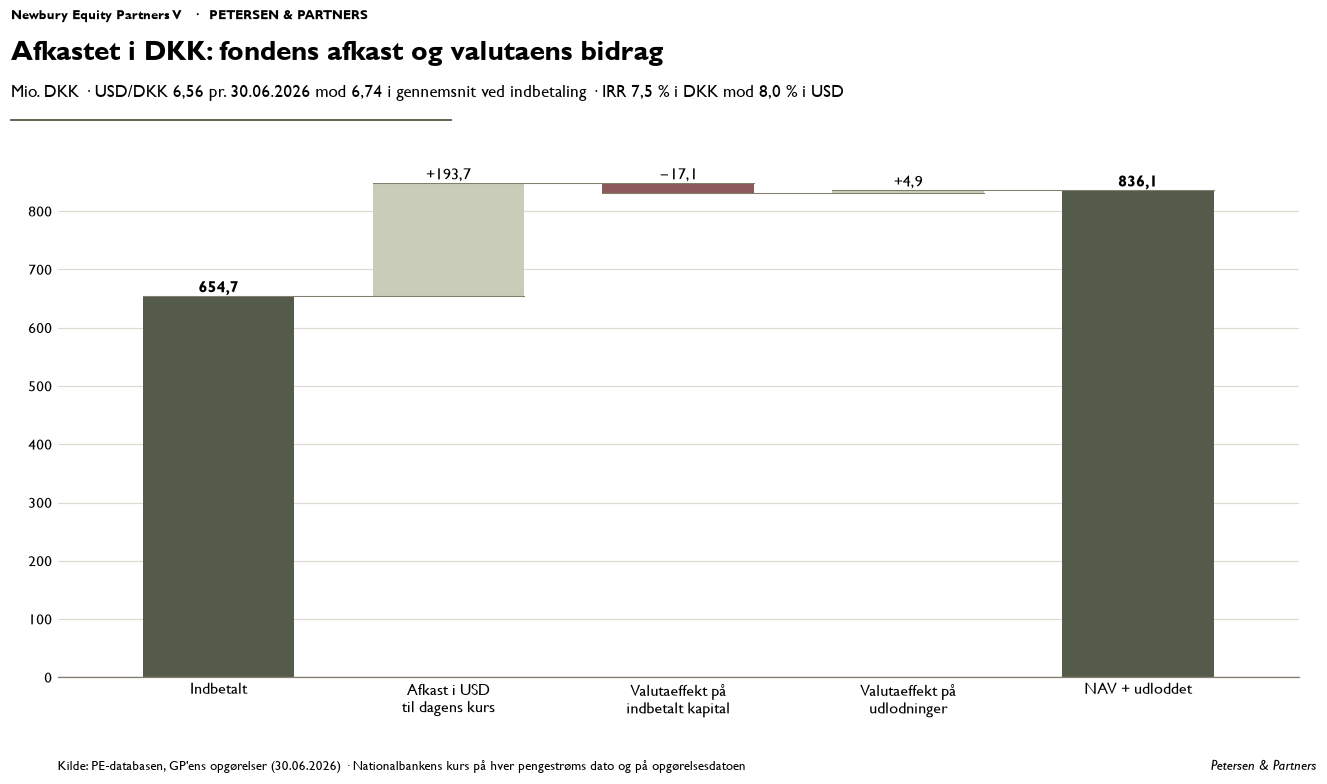

In [14]:
af.graf_valutabro()

gemt: charts\nep5_afkast_valuta_tid.png  (3200 x 1800 px · 16:9)


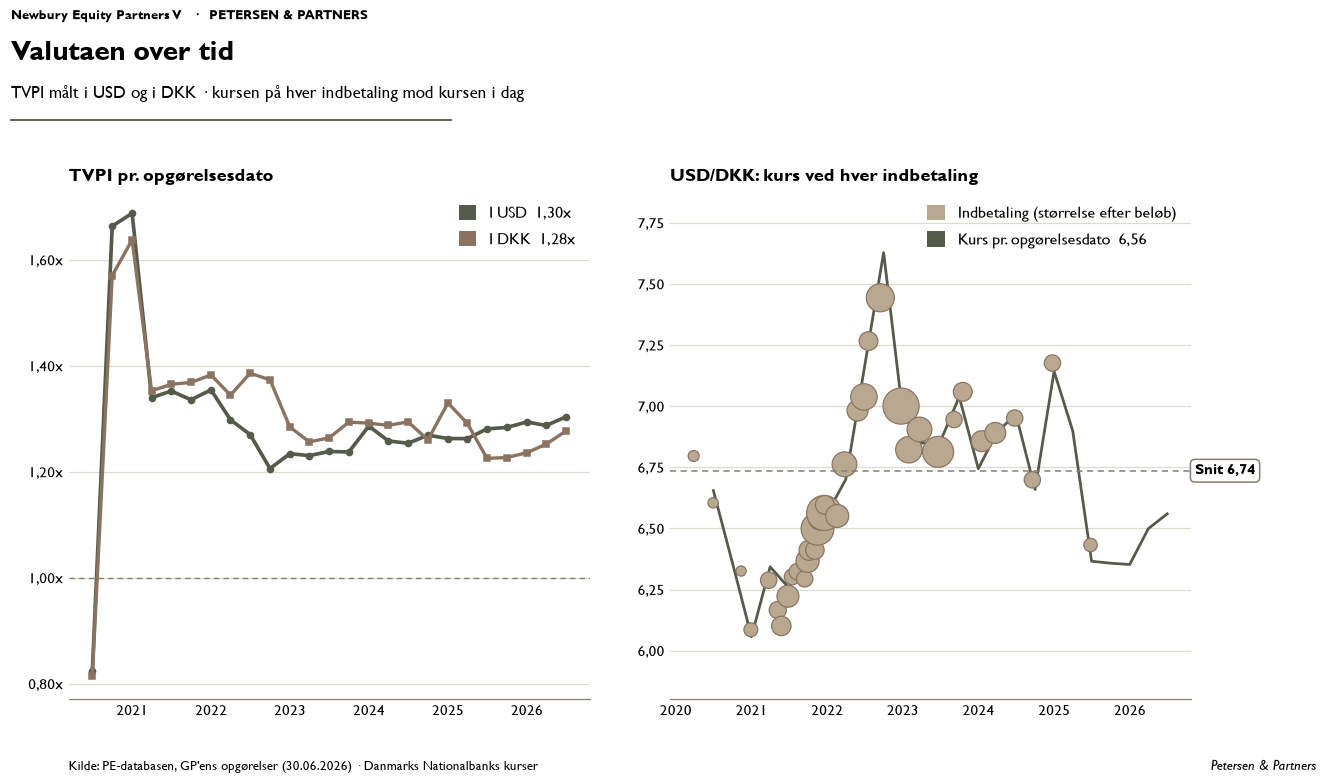

In [15]:
af.graf_valuta_tid()

# 5. Tabeller

De samme tal som graferne, men til at læse i.

gemt: charts\nep5_afkast_tabel_perioder_side1.png  (3200 x 1800 px · 16:9)


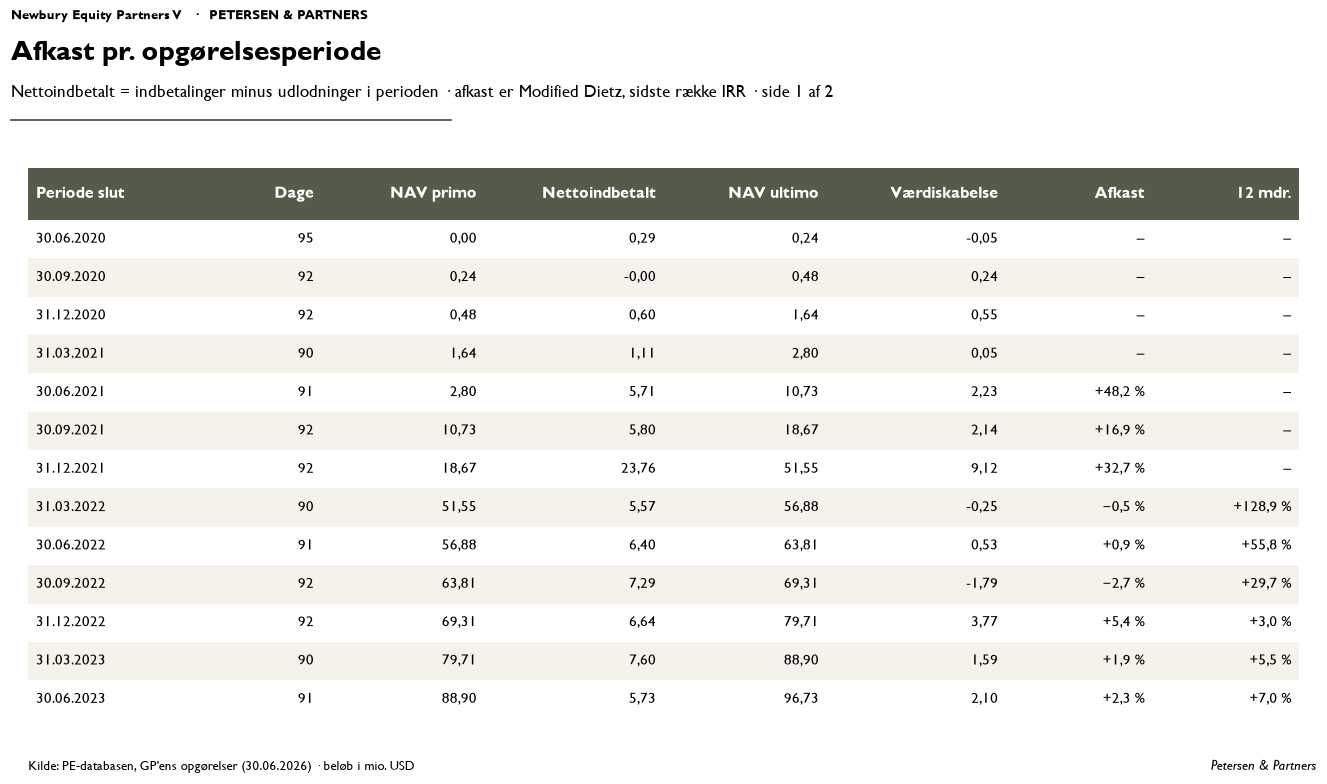

gemt: charts\nep5_afkast_tabel_perioder_side2.png  (3200 x 1800 px · 16:9)


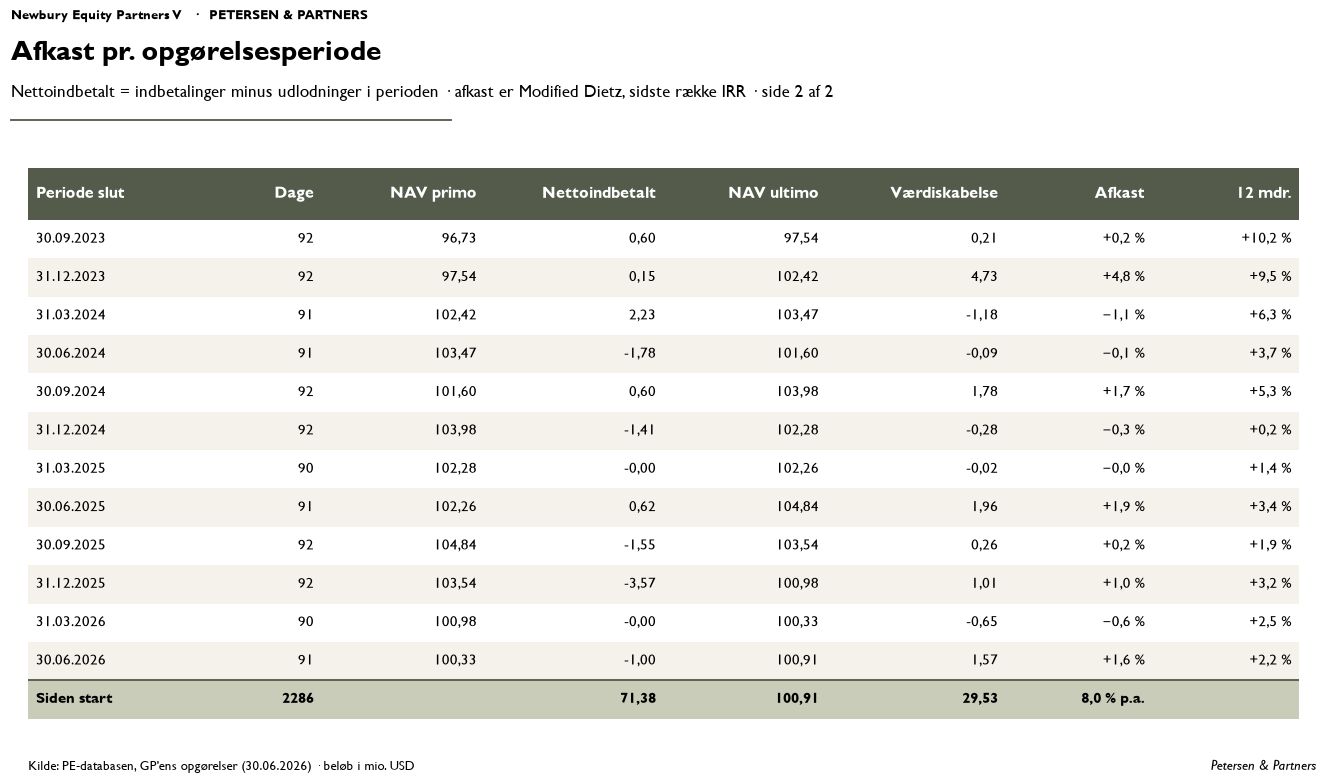

In [16]:
af.tabel_perioder()

gemt: charts\nep5_afkast_tabel_kilder.png  (3200 x 1800 px · 16:9)


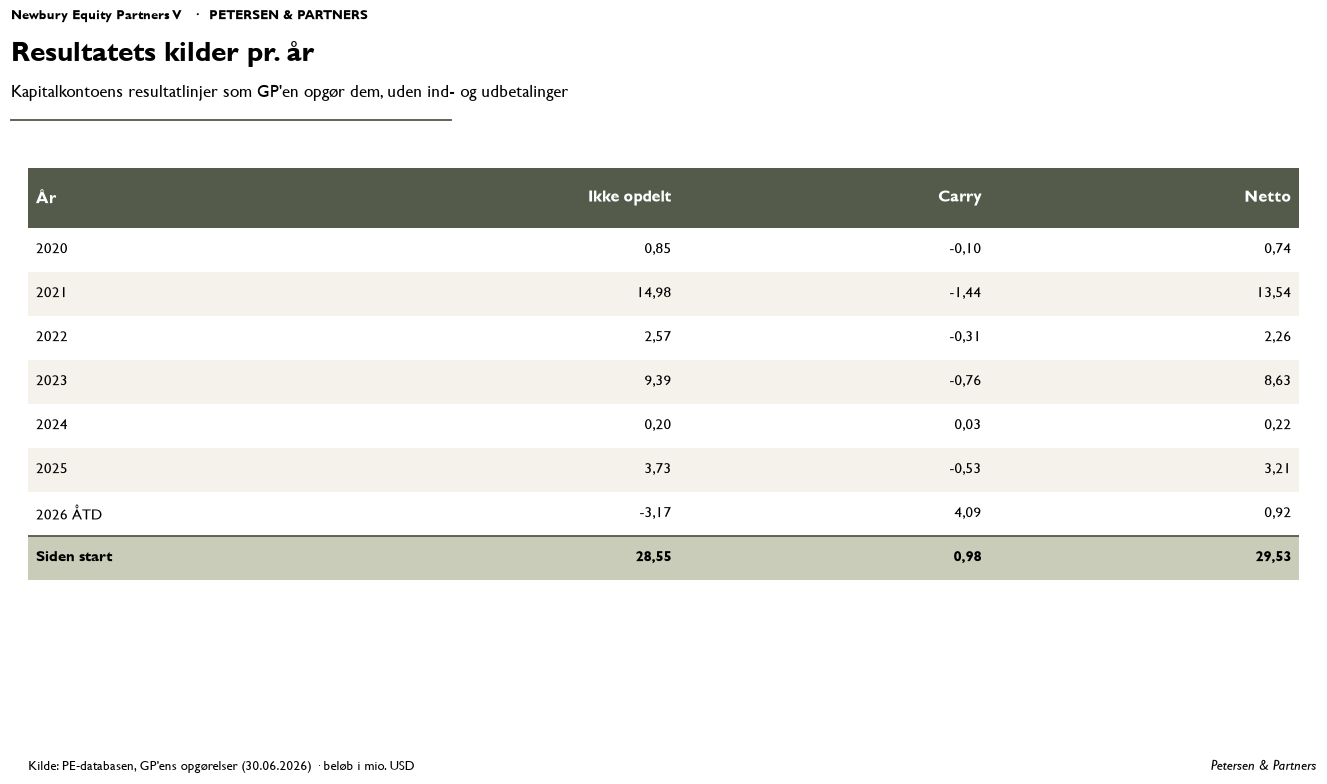

In [17]:
af.tabel_kilder()

In [18]:
af.tabel_omkostninger()

Ingen forvaltningshonorar udskilt i kapitalkontoen for NEP5 - springer over


# Eksport

Excel med alle tabellerne bag graferne, og ét deck på PPIM-masteren.

In [19]:
af.excel()

gemt: exports\nep5_afkast_30062026.xlsx  (12 ark)


WindowsPath('exports/nep5_afkast_30062026.xlsx')

In [20]:
af.deck()

gemt: exports\nep5_afkast_30062026.pptx  (23 slides)


WindowsPath('exports/nep5_afkast_30062026.pptx')